# EU Corpus: Clean → Score Pipeline

**Methodology:**
1. Load raw text and raw scores
2. Preprocess: lowercase, remove punctuation, remove stopwords
3. Re-score on cleaned text (higher, more meaningful percentages)
4. Compare raw vs. cleaned scores
5. Export final dataset

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns

# Download stopwords if needed
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

sns.set_style('whitegrid')
print("✓ Libraries ready")

✓ Libraries ready


## 1. Load Data

In [2]:
# Load corpus
CORPUS_DIR = Path('scraped')
corpus_files = sorted(CORPUS_DIR.glob('*_corpus.txt'))

documents = []
for filepath in corpus_files:
    parts = filepath.stem.split('_')
    year = int(parts[-2])
    country = '_'.join(parts[:-2])
    structural_format = 'narrative' if year <= 2023 else 'chapter-based'
    
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read()
    
    documents.append({
        'country': country,
        'year': year,
        'structural_format': structural_format,
        'raw_text': text,
        'raw_total_words': len(text.split())
    })

df = pd.DataFrame(documents).sort_values(['country', 'year']).reset_index(drop=True)
print(f"Loaded {len(df)} documents")

Loaded 35 documents


## 2. Preprocessing Pipeline

In [3]:
def preprocess_text(text):
    """
    Clean text for analysis:
    1. Lowercase
    2. Remove punctuation (keep hyphens for compound words)
    3. Tokenize
    4. Remove stopwords and short tokens
    """
    # Lowercase
    text = text.lower()
    
    # Remove punctuation but keep hyphens
    text = re.sub(r"[^\w\s-]", " ", text)
    
    # Tokenize
    tokens = text.split()
    
    # Remove stopwords and short tokens
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t and t not in stop_words and len(t) > 1]
    
    return tokens

# Apply preprocessing
print("Preprocessing all documents...")
df['cleaned_tokens'] = df['raw_text'].apply(preprocess_text)
df['cleaned_total_tokens'] = df['cleaned_tokens'].apply(len)
df['cleaned_text'] = df['cleaned_tokens'].apply(lambda x: ' '.join(x))

print(f"✓ Complete")
print(f"\nToken count comparison (sample):")
print(f"{'Country':<20} {'Year':>5} {'Raw Words':>12} {'Cleaned Tokens':>18} {'Reduction':>12}")
print("-" * 70)
for _, row in df.head(10).iterrows():
    reduction = (1 - row['cleaned_total_tokens'] / row['raw_total_words']) * 100
    print(f"{row['country'].replace('_', ' ').title():<20} {row['year']:>5} {row['raw_total_words']:>12} {row['cleaned_total_tokens']:>18} {reduction:>11.0f}%")

Preprocessing all documents...
✓ Complete

Token count comparison (sample):
Country               Year    Raw Words     Cleaned Tokens    Reduction
----------------------------------------------------------------------
Albania               2021         3574               2174          39%
Albania               2022         3369               2081          38%
Albania               2023         2979               1761          41%
Albania               2024         7830               4787          39%
Albania               2025         8509               5264          38%
Bosnia And Herzegovina  2021         2863               1713          40%
Bosnia And Herzegovina  2022         3483               2111          39%
Bosnia And Herzegovina  2023         3972               2443          38%
Bosnia And Herzegovina  2024         7894               4807          39%
Bosnia And Herzegovina  2025         7898               4732          40%


## 3. Score on Cleaned Text

In [4]:
# Dictionaries
reform_words = {
    'progress', 'progressed', 'advanced', 'advances', 'adopted', 'adopting',
    'implemented', 'implementing', 'strengthened', 'strengthens', 'strengthening',
    'improved', 'improving', 'improvement', 'established', 'establishing',
    'achieved', 'achieves', 'achievement', 'accelerated', 'accelerate',
    'completed', 'completion', 'completing', 'good', 'better', 'well',
    'success', 'successful', 'successfully', 'effective', 'effectively',
    'positive', 'positively', 'enhance', 'enhanced', 'enhancement',
    'functional', 'functioning', 'efficient', 'efficiency'
}

criticism_words = {
    'concern', 'concerns', 'concerning', 'weak', 'weaken', 'weakness',
    'lack', 'lacked', 'lacking', 'delayed', 'delay', 'delays',
    'limited', 'limiting', 'incomplete', 'incompleteness', 'decreased',
    'decrease', 'declining', 'decline', 'insufficient', 'insufficiently',
    'challenge', 'challenges', 'challenging', 'persisting', 'persist',
    'persistent', 'backsliding', 'backslide', 'difficult', 'difficulty',
    'fail', 'failed', 'failure', 'failing', 'problem', 'problems',
    'problematic', 'issue', 'issues', 'risk', 'risks', 'serious',
    'seriously', 'remain', 'remains', 'need', 'needs', 'needed',
    'required', 'require', 'worrying', 'worried', 'inadequate',
    'undermining', 'undermine', 'early', 'stage'
}

def score_tokens(tokens):
    """Score list of tokens."""
    total = len(tokens)
    reform_count = sum(1 for t in tokens if t in reform_words)
    criticism_count = sum(1 for t in tokens if t in criticism_words)
    
    reform_pct = (reform_count / total * 100) if total > 0 else 0
    criticism_pct = (criticism_count / total * 100) if total > 0 else 0
    net = reform_pct - criticism_pct
    
    return reform_count, criticism_count, reform_pct, criticism_pct, net

# Score cleaned text
print("Scoring cleaned text...")
scores = df['cleaned_tokens'].apply(lambda x: pd.Series(score_tokens(x)))
scores.columns = ['reform_count', 'criticism_count', 'reform_score', 'criticism_score', 'net_score']
df = pd.concat([df, scores], axis=1)

print(f"✓ Complete\n")
print(f"Scores on Cleaned Text:")
print(f"\n{'Country':<25} {'Year':>5} {'Format':<15} {'Reform%':>8} {'Crit%':>8}")
print("-" * 70)
for _, row in df.iterrows():
    country = row['country'].replace('_', ' ').title()
    print(f"{country:<25} {row['year']:>5} {row['structural_format']:<15} {row['reform_score']:>7.2f}% {row['criticism_score']:>7.2f}%")

print(f"\nOverall Statistics (Cleaned Text):")
print(f"  Mean Reform Score: {df['reform_score'].mean():.2f}%")
print(f"  Mean Criticism Score: {df['criticism_score'].mean():.2f}%")
print(f"  Mean Net Score: {df['net_score'].mean():.3f}")

Scoring cleaned text...
✓ Complete

Scores on Cleaned Text:

Country                    Year Format           Reform%    Crit%
----------------------------------------------------------------------
Albania                    2021 narrative          3.68%    2.44%
Albania                    2022 narrative          4.04%    3.22%
Albania                    2023 narrative          4.09%    3.58%
Albania                    2024 chapter-based      4.35%    2.53%
Albania                    2025 chapter-based      4.37%    2.68%
Bosnia And Herzegovina     2021 narrative          3.44%    4.09%
Bosnia And Herzegovina     2022 narrative          3.36%    3.65%
Bosnia And Herzegovina     2023 narrative          3.68%    3.68%
Bosnia And Herzegovina     2024 chapter-based      3.54%    3.66%
Bosnia And Herzegovina     2025 chapter-based      3.47%    3.42%
Kosovo                     2021 narrative          4.08%    4.91%
Kosovo                     2022 narrative          4.60%    3.45%
Kosovo    

## 4. Compare Raw vs. Cleaned Scores

In [5]:
# Compare with raw scores (from full text)
def score_raw_text(text):
    tokens = text.lower().split()
    total = len(tokens)
    reform_count = sum(1 for t in tokens if t in reform_words)
    criticism_count = sum(1 for t in tokens if t in criticism_words)
    reform_pct = (reform_count / total * 100) if total > 0 else 0
    criticism_pct = (criticism_count / total * 100) if total > 0 else 0
    return reform_pct, criticism_pct

raw_scores = df['raw_text'].apply(lambda x: pd.Series(score_raw_text(x)))
raw_scores.columns = ['raw_reform_score', 'raw_criticism_score']
df = pd.concat([df, raw_scores], axis=1)

# Compare
print("\nComparison: Raw vs. Cleaned Text Scoring\n")
print(f"{'Country':<25} {'Year':>5} {'Raw Reform':>12} {'Clean Reform':>14} {'Improvement':>12}")
print("-" * 75)
for _, row in df.iterrows():
    country = row['country'].replace('_', ' ').title()
    improvement = row['reform_score'] - row['raw_reform_score']
    print(f"{country:<25} {row['year']:>5} {row['raw_reform_score']:>11.2f}% {row['reform_score']:>13.2f}% {improvement:>11.2f}%")

print(f"\nAverage improvement in scores after cleaning:")
print(f"  Reform: {(df['reform_score'] - df['raw_reform_score']).mean():.2f} percentage points")
print(f"  Criticism: {(df['criticism_score'] - df['raw_criticism_score']).mean():.2f} percentage points")


Comparison: Raw vs. Cleaned Text Scoring

Country                    Year   Raw Reform   Clean Reform  Improvement
---------------------------------------------------------------------------
Albania                    2021        1.85%          3.68%        1.83%
Albania                    2022        2.02%          4.04%        2.02%
Albania                    2023        1.98%          4.09%        2.11%
Albania                    2024        2.44%          4.35%        1.91%
Albania                    2025        2.40%          4.37%        1.97%
Bosnia And Herzegovina     2021        1.78%          3.44%        1.66%
Bosnia And Herzegovina     2022        1.72%          3.36%        1.64%
Bosnia And Herzegovina     2023        1.94%          3.68%        1.75%
Bosnia And Herzegovina     2024        1.89%          3.54%        1.65%
Bosnia And Herzegovina     2025        1.87%          3.47%        1.59%
Kosovo                     2021        2.17%          4.08%        1.90%
Kosov

## 5. Visualize Cleaned Scores

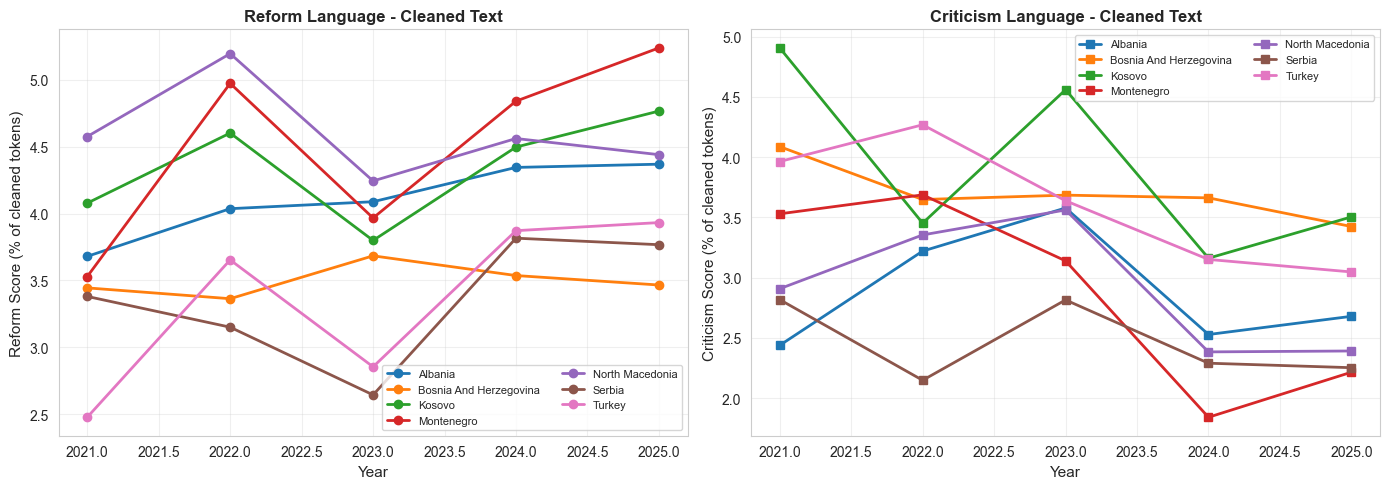

✓ Saved as 'EU_corpus_cleaned_scores.png'


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reform scores by country
ax = axes[0]
for country in sorted(df['country'].unique()):
    country_df = df[df['country'] == country].sort_values('year')
    ax.plot(country_df['year'], country_df['reform_score'], marker='o', 
            label=country.replace('_', ' ').title(), linewidth=2, markersize=6)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Reform Score (% of cleaned tokens)', fontsize=11)
ax.set_title('Reform Language - Cleaned Text', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Criticism scores by country
ax = axes[1]
for country in sorted(df['country'].unique()):
    country_df = df[df['country'] == country].sort_values('year')
    ax.plot(country_df['year'], country_df['criticism_score'], marker='s', 
            label=country.replace('_', ' ').title(), linewidth=2, markersize=6)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Criticism Score (% of cleaned tokens)', fontsize=11)
ax.set_title('Criticism Language - Cleaned Text', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('EU_corpus_cleaned_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved as 'EU_corpus_cleaned_scores.png'")

## 6. Export Final Dataset

In [7]:
# Export final dataset
export_df = df[[
    'country', 'year', 'structural_format',
    'raw_total_words', 'cleaned_total_tokens',
    'reform_count', 'criticism_count',
    'reform_score', 'criticism_score', 'net_score'
]].copy()

export_df.to_csv('EU_corpus_final_cleaned.csv', index=False)
print("✓ Final dataset exported to 'EU_corpus_final_cleaned.csv'\n")
print(export_df.to_string(index=False))

✓ Final dataset exported to 'EU_corpus_final_cleaned.csv'

               country  year structural_format  raw_total_words  cleaned_total_tokens  reform_count  criticism_count  reform_score  criticism_score  net_score
               albania  2021         narrative             3574                  2174          80.0             53.0      3.679853         2.437902   1.241950
               albania  2022         narrative             3369                  2081          84.0             67.0      4.036521         3.219606   0.816915
               albania  2023         narrative             2979                  1761          72.0             63.0      4.088586         3.577513   0.511073
               albania  2024     chapter-based             7830                  4787         208.0            121.0      4.345101         2.527679   1.817422
               albania  2025     chapter-based             8509                  5264         230.0            141.0      4.369301         2.67857

## 7. Summary for Paper

In [8]:
print("\n" + "="*75)
print("FINAL DATASET SUMMARY (Cleaned Text)")
print("="*75)

print(f"\nSample:")
print(f"  N = {len(df)} observations (7 countries × 5 years)")
print(f"  Raw tokens: {df['raw_total_words'].sum():,}")
print(f"  Cleaned tokens: {df['cleaned_total_tokens'].sum():,}")
print(f"  Reduction: {(1 - df['cleaned_total_tokens'].sum()/df['raw_total_words'].sum())*100:.1f}%")

print(f"\nMain Variables (on cleaned text):")
print(f"\n  Reform Score (%)")
print(f"    Mean: {df['reform_score'].mean():.2f}")
print(f"    SD: {df['reform_score'].std():.2f}")
print(f"    Range: [{df['reform_score'].min():.2f}, {df['reform_score'].max():.2f}]")

print(f"\n  Criticism Score (%)")
print(f"    Mean: {df['criticism_score'].mean():.2f}")
print(f"    SD: {df['criticism_score'].std():.2f}")
print(f"    Range: [{df['criticism_score'].min():.2f}, {df['criticism_score'].max():.2f}]")

print(f"\n  Net Score (Reform - Criticism)")
print(f"    Mean: {df['net_score'].mean():.3f}")
print(f"    SD: {df['net_score'].std():.3f}")
print(f"    Range: [{df['net_score'].min():.3f}, {df['net_score'].max():.3f}]")

print(f"\nVariation by Structural Format:")
for fmt in sorted(df['structural_format'].unique()):
    subset = df[df['structural_format']==fmt]
    print(f"  {fmt} (n={len(subset)}):")
    print(f"    Reform: {subset['reform_score'].mean():.2f} (SD: {subset['reform_score'].std():.2f})")
    print(f"    Criticism: {subset['criticism_score'].mean():.2f} (SD: {subset['criticism_score'].std():.2f})")

print(f"\n" + "="*75)
print("✓ READY FOR ANALYSIS")
print("="*75)


FINAL DATASET SUMMARY (Cleaned Text)

Sample:
  N = 35 observations (7 countries × 5 years)
  Raw tokens: 188,566
  Cleaned tokens: 114,652
  Reduction: 39.2%

Main Variables (on cleaned text):

  Reform Score (%)
    Mean: 3.97
    SD: 0.67
    Range: [2.48, 5.24]

  Criticism Score (%)
    Mean: 3.20
    SD: 0.72
    Range: [1.84, 4.91]

  Net Score (Reform - Criticism)
    Mean: 0.770
    SD: 1.097
    Range: [-1.486, 3.024]

Variation by Structural Format:
  chapter-based (n=14):
    Reform: 4.25 (SD: 0.53)
    Criticism: 2.75 (SD: 0.57)
  narrative (n=21):
    Reform: 3.78 (SD: 0.71)
    Criticism: 3.49 (SD: 0.66)

✓ READY FOR ANALYSIS
